In [1]:
import sys
sys.path.append('../src')

In [2]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

In [3]:
from context_manager import TriangleIntegrandContext
from integrand_builder import IntegrandBuilder


centered_config = True

ctx = TriangleIntegrandContext()

ib = IntegrandBuilder()
ib.check_singularities_per_sample = False # not necessary for this example, improves performance

if centered_config:
    ib.center_counterterm_region_at_origin = True
    ib.smooth_mask = False
    ctx.subtraction_width = 2.5
    ctx.mask_width = 2.5
    folder = 'centered'
else:
    ib.center_counterterm_region_at_origin = False
    ib.smooth_mask = True
    ctx.subtraction_width = 1
    ctx.mask_width = 1
    folder = 'uncentered'
    

In [4]:
from context_manager import TriangleIntegrandEvaluator
from wrapped_eval import WrappedEvaluator


tie = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib.combined_result(), ib.get_args(), "combined_result"), ctx
)

Compiling evaluator: "combined_result"
Done!


# plot the integrand and threshold subtraction

In [5]:
from context_manager import norm

ctx.set_external_momenta(1, 3, 8)
qs, _ = ctx.get_ordered_qs_and_masses()

threshold_masses = [norm((qs[i]-qs[j])/2)**0.5 for (i,j) in [(0,1), (1,2), (0,2)]]
print(threshold_masses)

[np.float64(0.8660254037844386), np.float64(0.5), np.float64(1.414213562373095)]


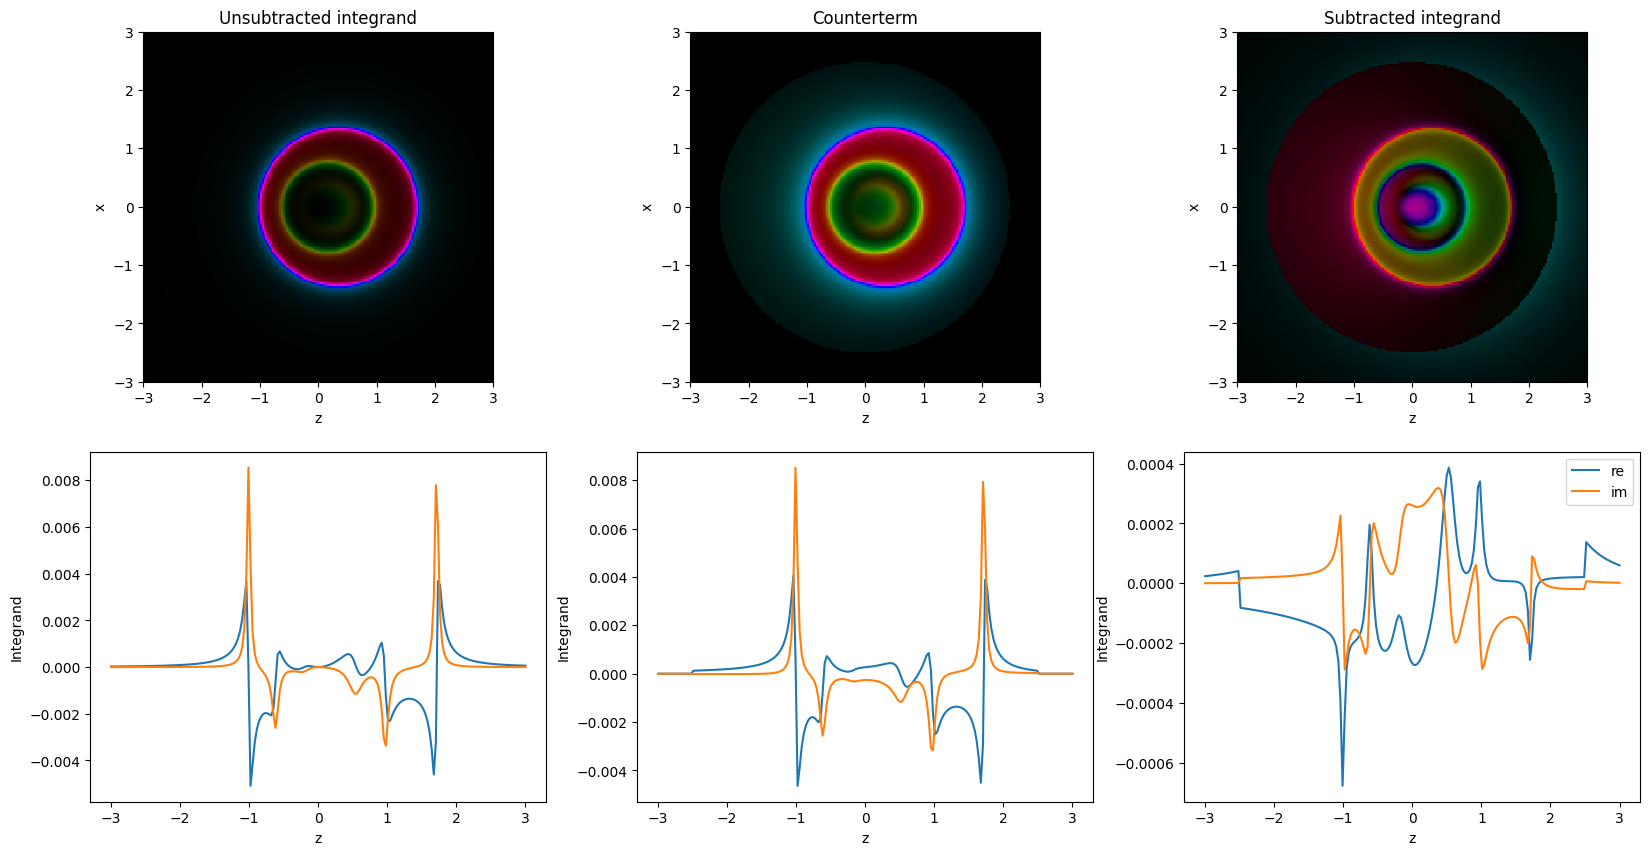

/tmp/ipykernel_15743/3981034696.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


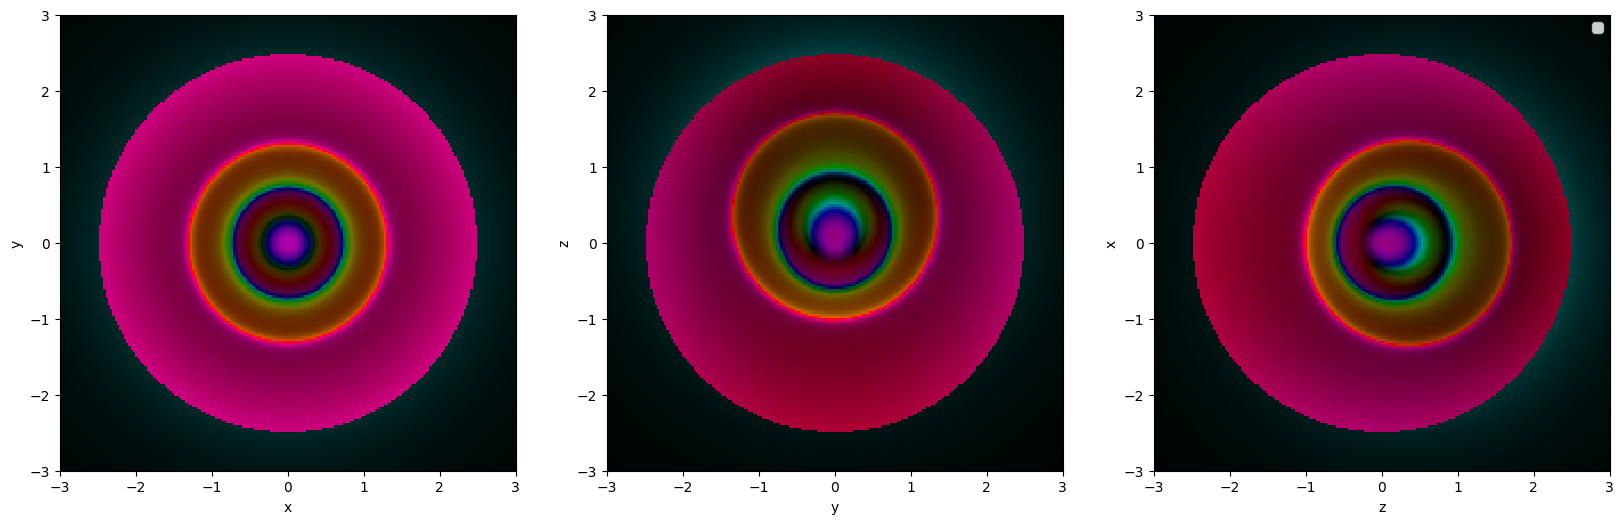

In [6]:


mass = 0.4-0.1j
ctx.masses = [mass, mass, mass]
tie.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.legend()
plt.savefig(f"../images/{folder}/threshold_subtraction.png", dpi=300)
plt.show()
ctx.combined_integrand()
tie.plot_planes((-3,3),(-3,3), divide_jacobian = True,res = 200)
plt.legend()
plt.show()

In [7]:
from symbolica import RandomNumberGenerator
rng = RandomNumberGenerator(0,0)

In [8]:
from context_manager import spherical
from integrator import ComplexIntegrator


def integrate_over_masses(masses, triangle, epochs = 100, steps = 500):
    results = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        results.append(ci.integrate(triangle.eval, spherical, epochs, steps, rng))
        
        
    return results

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

In [9]:
mass = 0.4
sample_masses = mass - 0.1j*0.0001**np.linspace(0,1,21)
ref_masses = mass - 0.1j*0.0001**np.linspace(0,1,50)

ctx.combined_integrand()
global_check_res = integrate_over_masses(sample_masses, tie)

ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

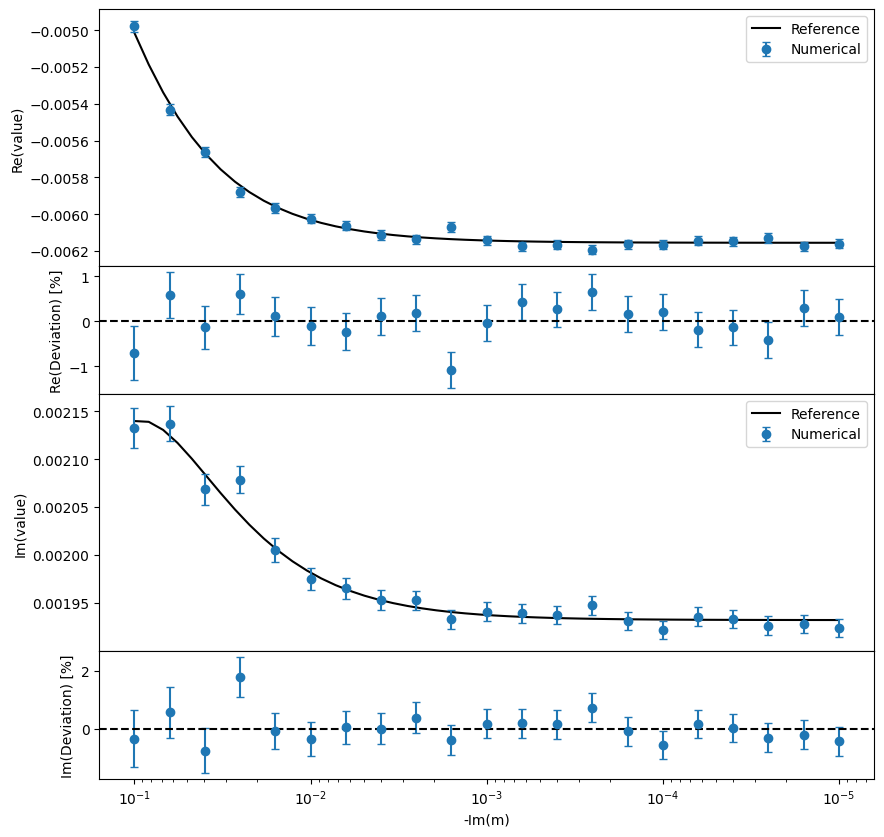

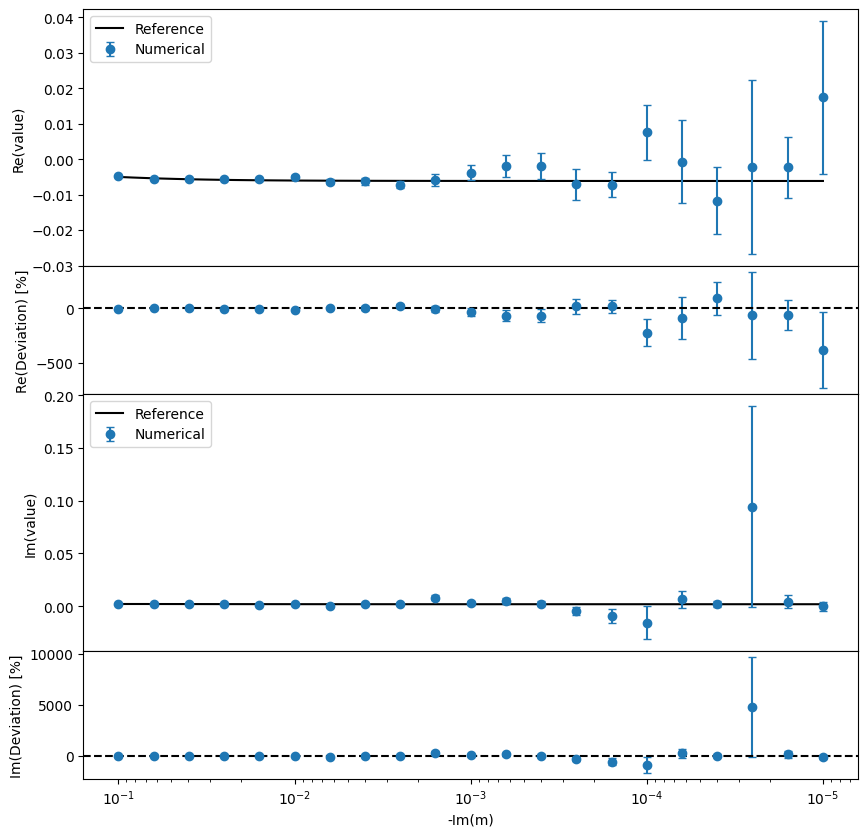

In [10]:
from plot_util import plot_complex_integration_with_ref


ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.savefig(f"../images/{folder}/integration_small_width_subtracted.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.savefig(f"../images/{folder}/integration_small_width_unsubtracted.png", dpi=300)
plt.show()

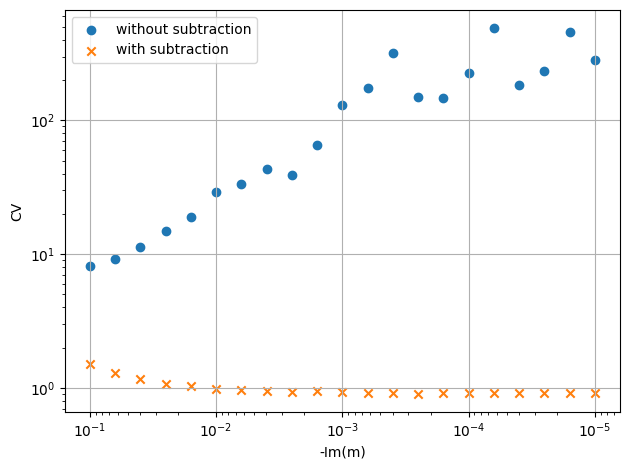

In [11]:
plt.scatter(-sample_masses.imag, [r.cv() for r in unsub_res], label = 'without subtraction', marker='o')
plt.scatter(-sample_masses.imag, [r.cv() for r in global_check_res],  label = 'with subtraction', marker='x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('-Im(m)')
plt.ylabel('CV')
plt.gca().xaxis.set_inverted(True)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"../images/{folder}/cv_small_width.png", dpi=300)
plt.show()

In [12]:
sample_masses = np.linspace(0.2,2,21)
ref_masses = np.linspace(0.2,2,200)

ctx.combined_integrand()
ctx.max_eta_min = 0
global_check_res = integrate_over_masses(sample_masses, tie)
ctx.max_eta_min = 1e10
per_sample_check = integrate_over_masses(sample_masses, tie)


ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

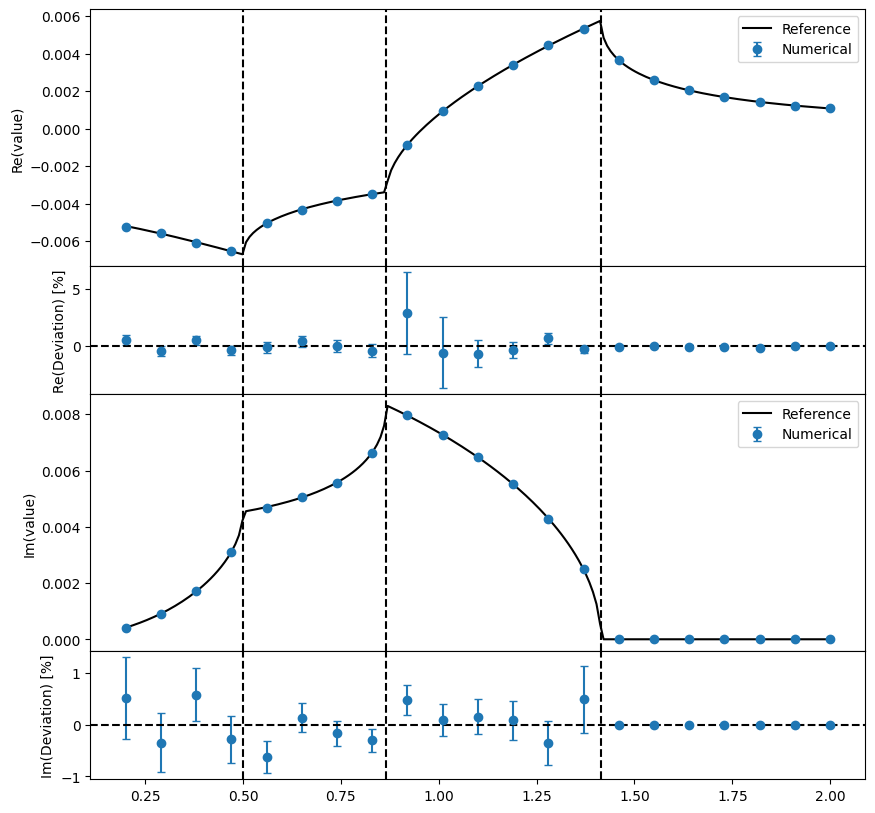

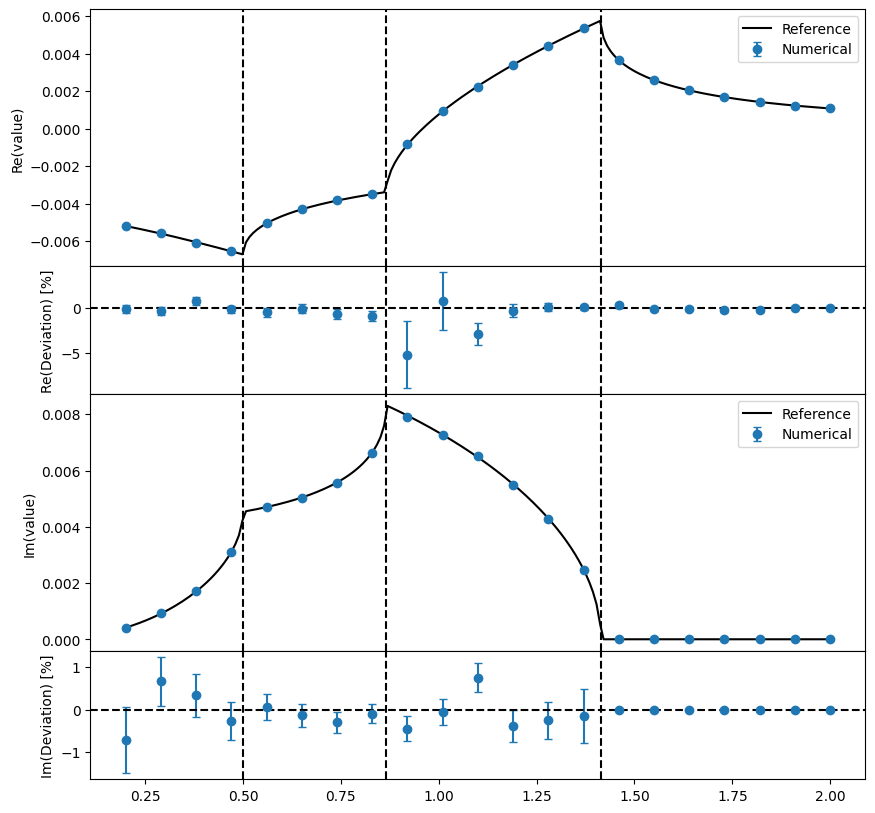

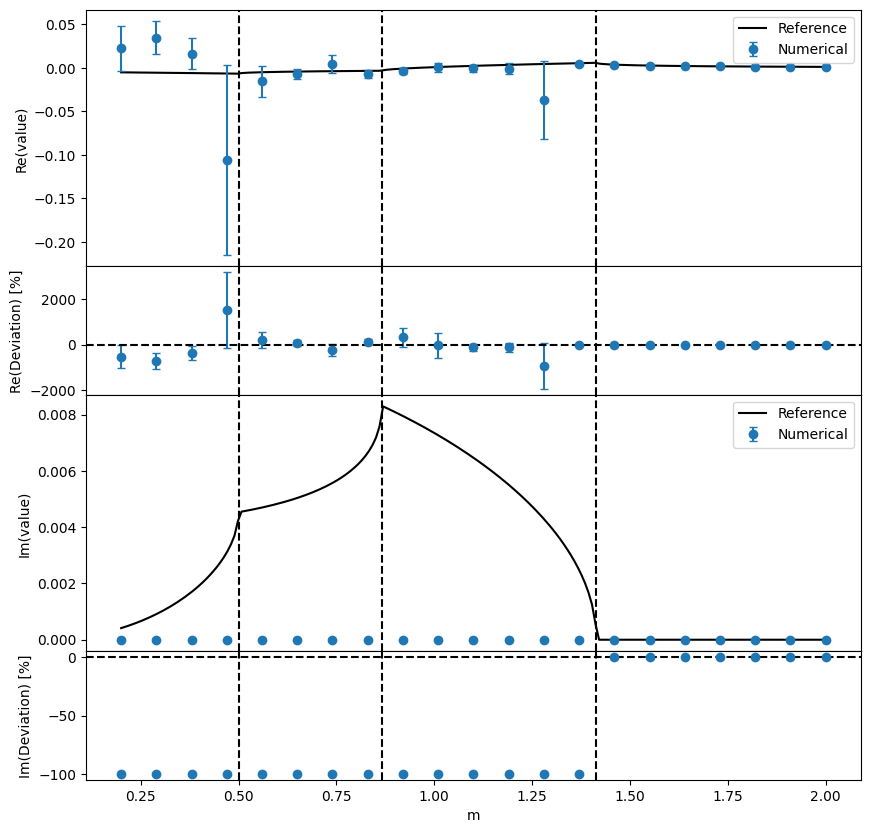

In [13]:
ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    for m in threshold_masses:
        ax.axvline(m, ls = "--", c = "black")
plt.savefig(f"../images/{folder}/integration_threshold_masses_global.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    per_sample_check, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    for m in threshold_masses:
        ax.axvline(m, ls = "--", c = "black")
plt.savefig(f"../images/{folder}/integration_threshold_masses_per_sample.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    for m in threshold_masses:
        ax.axvline(m, ls = "--", c = "black")
fig.get_axes()[-1].set_xlabel('m')
plt.savefig(f"../images/{folder}/integration_threshold_masses_unsubtracted.png", dpi=300)
plt.show()

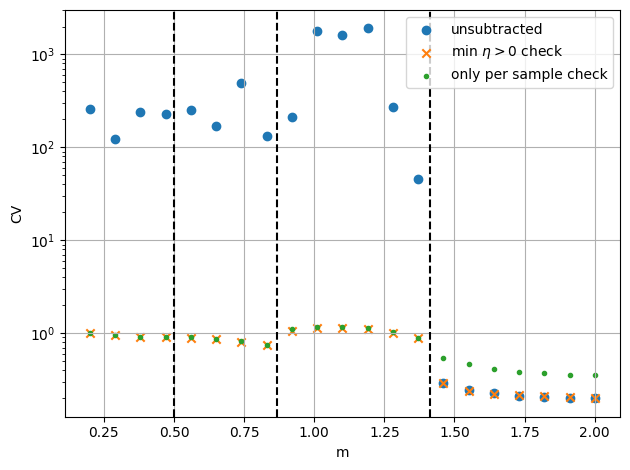

In [14]:
plt.scatter(sample_masses, [r.cv() for r in unsub_res], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, [r.cv() for r in global_check_res], label = 'min $\\eta > 0$ check', marker = 'x')
plt.scatter(sample_masses, [r.cv() for r in per_sample_check], label = 'only per sample check', marker = '.')
plt.yscale('log')
for m in threshold_masses:
    plt.axvline(m, ls = "--", c = "black")
plt.grid(True)
plt.xlabel('m')
plt.ylabel('CV')
plt.legend()
plt.tight_layout()

plt.savefig(f"../images/{folder}/cv_threshold_masses.png", dpi=300)
plt.show()


In [15]:
c = np.sqrt(2)
d = 1e-4

ref_masses = np.linspace(c-d,c+d,200)
sample_masses = np.linspace(c-d,c+d,21)

ctx.combined_integrand()
ctx.max_eta_min = 0
global_check_res = integrate_over_masses(sample_masses, tie)
ctx.max_eta_min = 1e10
per_sample_check = integrate_over_masses(sample_masses, tie)


ctx.only_unsubtracted()
unsub_res = integrate_over_masses(sample_masses, tie)

ref = reference_over_masses(ref_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

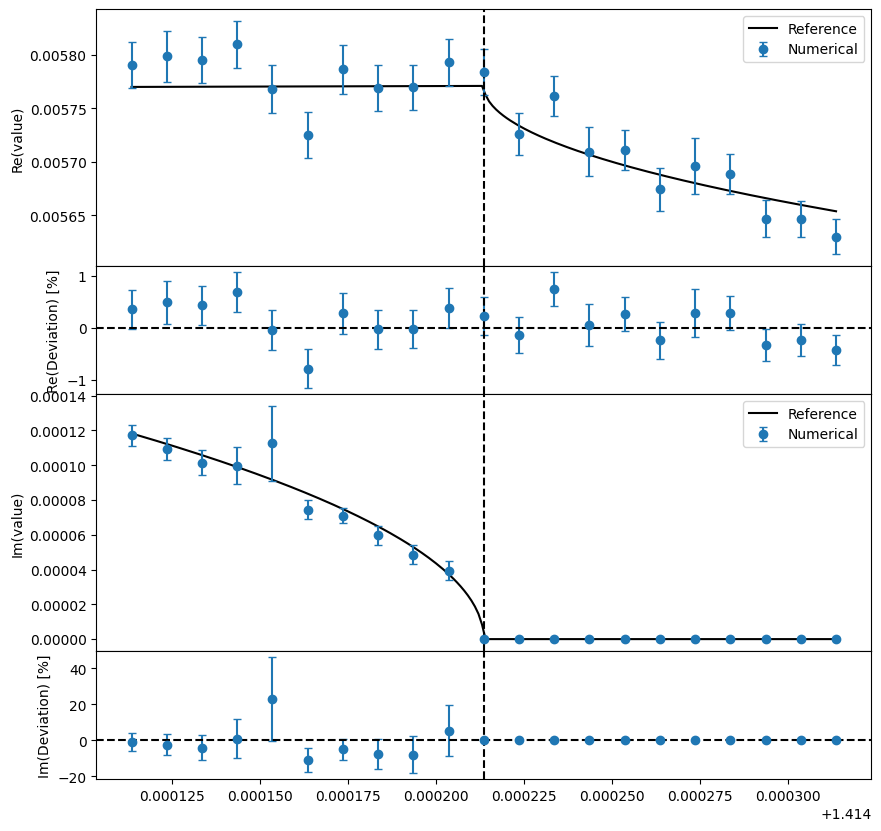

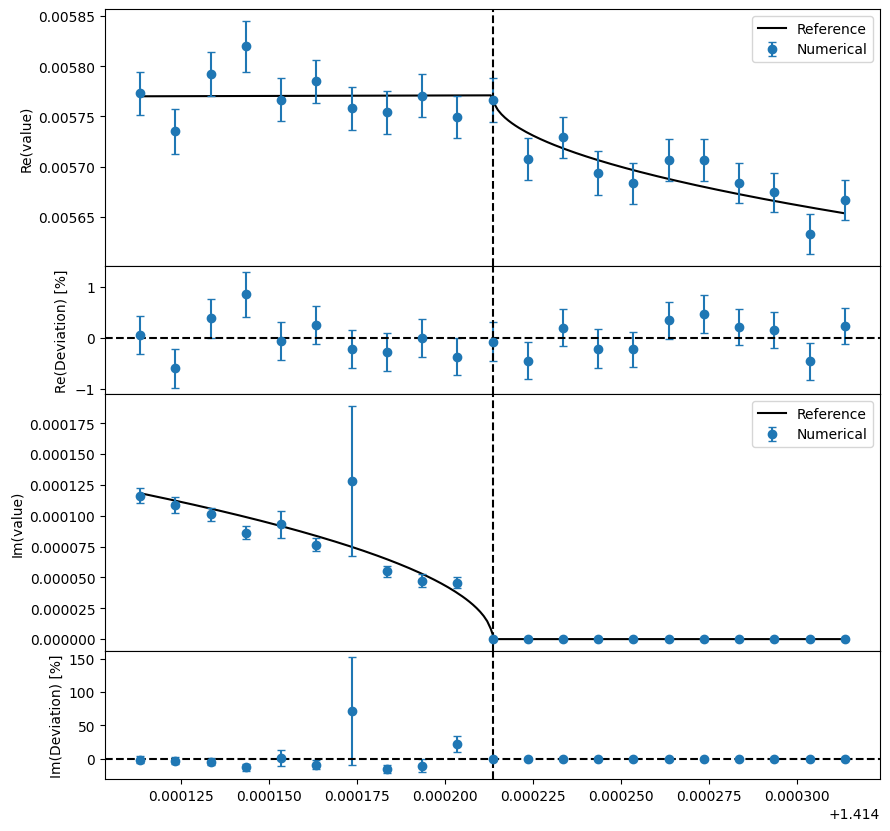

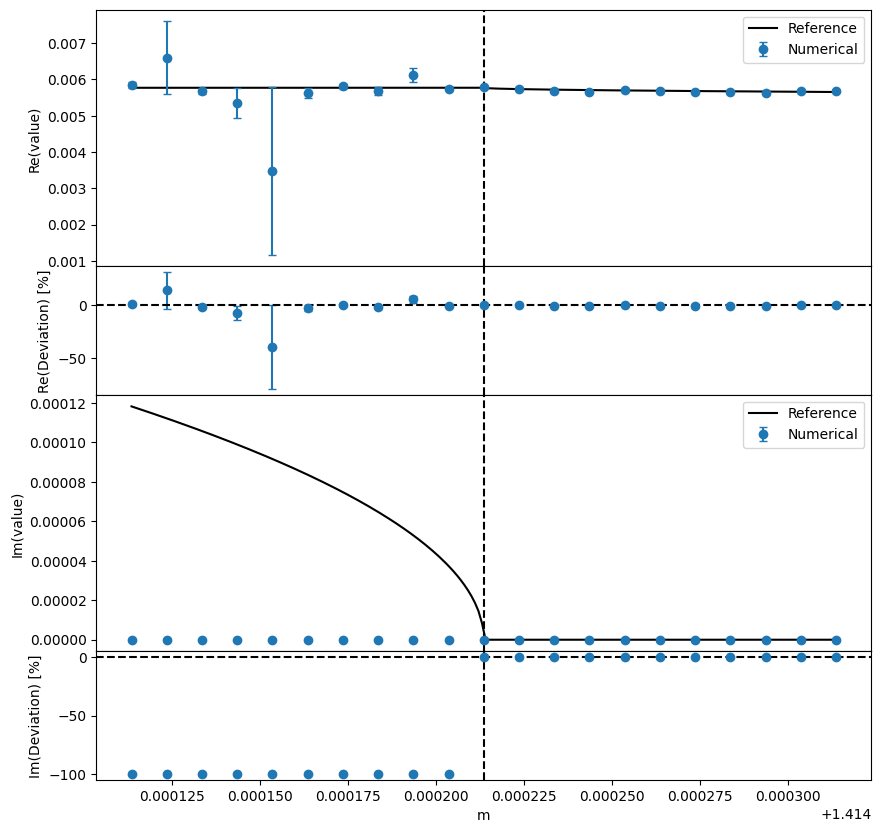

In [16]:
ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    global_check_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
plt.savefig(f"../images/{folder}/integration_threshold_masses_global_zoomed.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    per_sample_check, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
plt.savefig(f"../images/{folder}/integration_threshold_masses_per_sample_zoomed.png", dpi=300)
plt.show()

fig = plot_complex_integration_with_ref(
    unsub_res, ref_same_x, sample_masses, ref, ref_masses
)
for ax in fig.get_axes():
    ax.axvline(threshold_masses[2], ls = "--", c = "black")
fig.get_axes()[-1].set_xlabel('m')
plt.savefig(f"../images/{folder}/integration_threshold_masses_unsubtracted_zoomed.png", dpi=300)
plt.show()

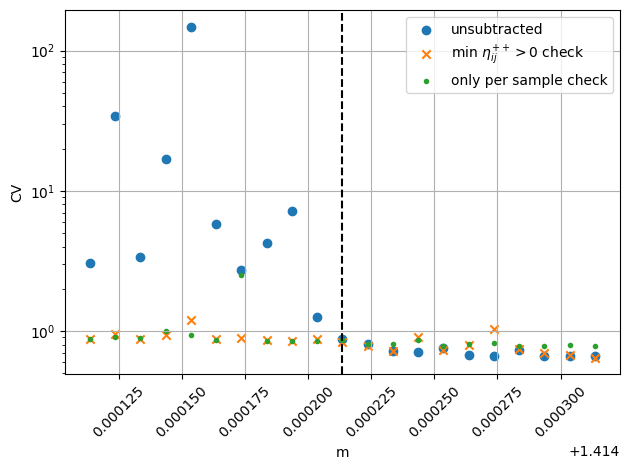

In [17]:
plt.scatter(sample_masses, [r.cv() for r in unsub_res], label = 'unsubtracted', marker='o')
plt.scatter(sample_masses, [r.cv() for r in global_check_res], label = 'min $\\eta^{++}_{ij} > 0$ check', marker = 'x')
plt.scatter(sample_masses, [r.cv() for r in per_sample_check], label = 'only per sample check', marker = '.')
plt.yscale('log')
plt.axvline(threshold_masses[2], ls = "--", c = "black")
plt.grid(True)
plt.xlabel('m')
plt.ylabel('CV')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(f"../images/{folder}/cv_threshold_masses_zoomed.png", dpi=300)
plt.show()
